--- Processing Strategy 1 ---
Strategy 1 processed.
--- Processing Strategy 2 ---
Strategy 2 processed.
--- Processing Strategy 3 ---
Strategy 3 processed.

--- Generating final plot ---
Final plot saved as 'figure_power_consumption_all_strategies.png'


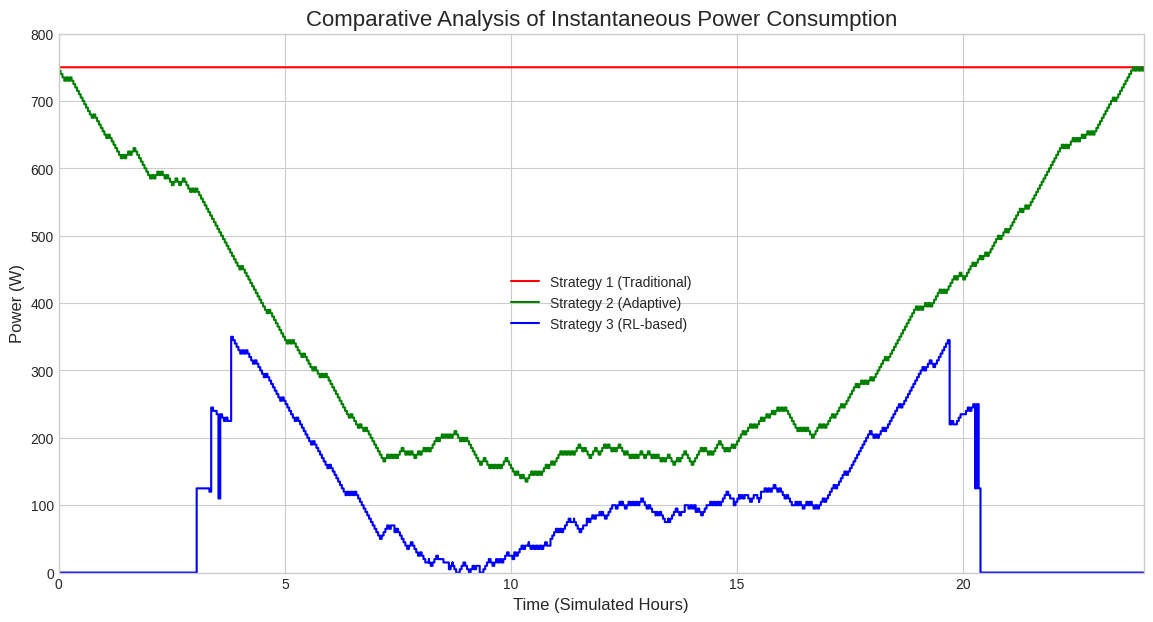

In [1]:
# ===================================================================
# STEP 1: IMPORT LIBRARIES AND DEFINE CONSTANTS
# ===================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

N_TOTAL = 150
N_PER_FLOOR = 50
P_LED = 5  # in Watts
ACTIVATION_THRESHOLD = 25 # 50% threshold

# ===================================================================
# STEP 2: PROCESS THE FILE FOR STRATEGY 1 (TRADITIONAL)
# ===================================================================
print("--- Processing Strategy 1 ---")
df_s1 = pd.read_csv('report_S1_run1.csv', skipfooter=4, engine='python')
df_s1['Timestamp'] = pd.to_datetime(df_s1['Timestamp'])
df_s1['power_S1'] = N_TOTAL * P_LED
start_time_s1 = df_s1['Timestamp'].min()
duration_s1 = (df_s1['Timestamp'].max() - start_time_s1).total_seconds()
df_s1['simulated_hours'] = (df_s1['Timestamp'] - start_time_s1).dt.total_seconds() * 24 / duration_s1
print("Strategy 1 processed.")

# ===================================================================
# STEP 3: PROCESS THE FILE FOR STRATEGY 2 (ADAPTIVE)
# ===================================================================
print("--- Processing Strategy 2 ---")
df_s2 = pd.read_csv('report_S2_run1.csv', skipfooter=4, engine='python')
df_s2['Timestamp'] = pd.to_datetime(df_s2['Timestamp'])

# Reconstruct total occupancy
occupied_spots_count = []
current_occupied = 0
for event_type in df_s2['Event Type']:
    if event_type == 'ARRIVAL': current_occupied += 1
    elif event_type == 'EXIT': current_occupied -= 1
    current_occupied = max(0, current_occupied)
    occupied_spots_count.append(current_occupied)
df_s2['total_occupied_spots'] = occupied_spots_count
df_s2['power_S2'] = (N_TOTAL - df_s2['total_occupied_spots']) * P_LED

# Normalize time
start_time_s2 = df_s2['Timestamp'].min()
duration_s2 = (df_s2['Timestamp'].max() - start_time_s2).total_seconds()
df_s2['simulated_hours'] = (df_s2['Timestamp'] - start_time_s2).dt.total_seconds() * 24 / duration_s2
print("Strategy 2 processed.")

# ===================================================================
# STEP 4: PROCESS THE FILE FOR STRATEGY 3 (RL)
# ===================================================================
print("--- Processing Strategy 3 ---")
# Using the median run, report_S3_run0.csv
df_s3 = pd.read_csv('report_S3_run1.csv', skipfooter=3, engine='python')
df_s3['Timestamp'] = pd.to_datetime(df_s3['Timestamp'], errors='coerce')
df_s3 = df_s3.dropna(subset=['Timestamp', 'Event Type', 'Assigned Spot'])

# Reconstruct per-floor occupancy
counts = {1: 0, 2: 0, 3: 0}
floor_occupancy_data = []
for index, row in df_s3.iterrows():
    try:
        floor = int(row['Assigned Spot'].split(':')[0])
        if row['Event Type'] == 'ARRIVAL': counts[floor] += 1
        elif row['Event Type'] == 'EXIT': counts[floor] -= 1
        counts = {k: max(0, v) for k, v in counts.items()}
    except (ValueError, IndexError): continue
    floor_occupancy_data.append(counts.copy())
df_occupancy = pd.DataFrame(floor_occupancy_data)
df_s3 = pd.concat([df_s3.reset_index(drop=True), df_occupancy.reset_index(drop=True)], axis=1)
df_s3.rename(columns={1: 'occupied_floor_1', 2: 'occupied_floor_2', 3: 'occupied_floor_3'}, inplace=True)

# Calculate power for Strategy 3
def calculate_power_s3(row):
    power = 0
    if row.get('occupied_floor_1', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_1']) * P_LED
    if row.get('occupied_floor_2', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_2']) * P_LED
    if row.get('occupied_floor_3', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_3']) * P_LED
    return power
df_s3['power_S3'] = df_s3.apply(calculate_power_s3, axis=1)

# Normalize time
start_time_s3 = df_s3['Timestamp'].min()
duration_s3 = (df_s3['Timestamp'].max() - start_time_s3).total_seconds()
df_s3['simulated_hours'] = (df_s3['Timestamp'] - start_time_s3).dt.total_seconds() * 24 / duration_s3
print("Strategy 3 processed.")

# ===================================================================
# STEP 5: PLOT THE FINAL COMPARATIVE GRAPH
# ===================================================================
print("\n--- Generating final plot ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each strategy using 'step' for accuracy
ax.step(df_s1['simulated_hours'], df_s1['power_S1'], where='post', label='Strategy 1 (Traditional)', color='red')
ax.step(df_s2['simulated_hours'], df_s2['power_S2'], where='post', label='Strategy 2 (Adaptive)', color='green')
ax.step(df_s3['simulated_hours'], df_s3['power_S3'], where='post', label='Strategy 3 (RL-based)', color='blue')

# Format the plot
ax.set_title('Comparative Analysis of Instantaneous Power Consumption', fontsize=16)
ax.set_xlabel('Time (Simulated Hours)', fontsize=12)
ax.set_ylabel('Power (W)', fontsize=12)
ax.set_xlim(0, 24)
ax.set_ylim(0, (N_TOTAL * P_LED) + 50)
ax.legend()
ax.grid(True)

# Save and show
plt.savefig('figure_power_consumption_all_strategies.png', dpi=300)
print("Final plot saved as 'figure_power_consumption_all_strategies.png'")
plt.show()

--- Préparation des données de puissance ---
Données de puissance préparées.

--- Calcul de l'énergie cumulative ---
Énergie totale S1 (Traditionnelle): 18000.00 Wh
Énergie totale S2 (Adaptative): 8612.17 Wh
Énergie totale S3 (RL-based): 3278.26 Wh

--- Génération du graphique d'énergie cumulative ---
Graphique d'énergie cumulative sauvegardé sous 'figure_cumulative_energy.png'


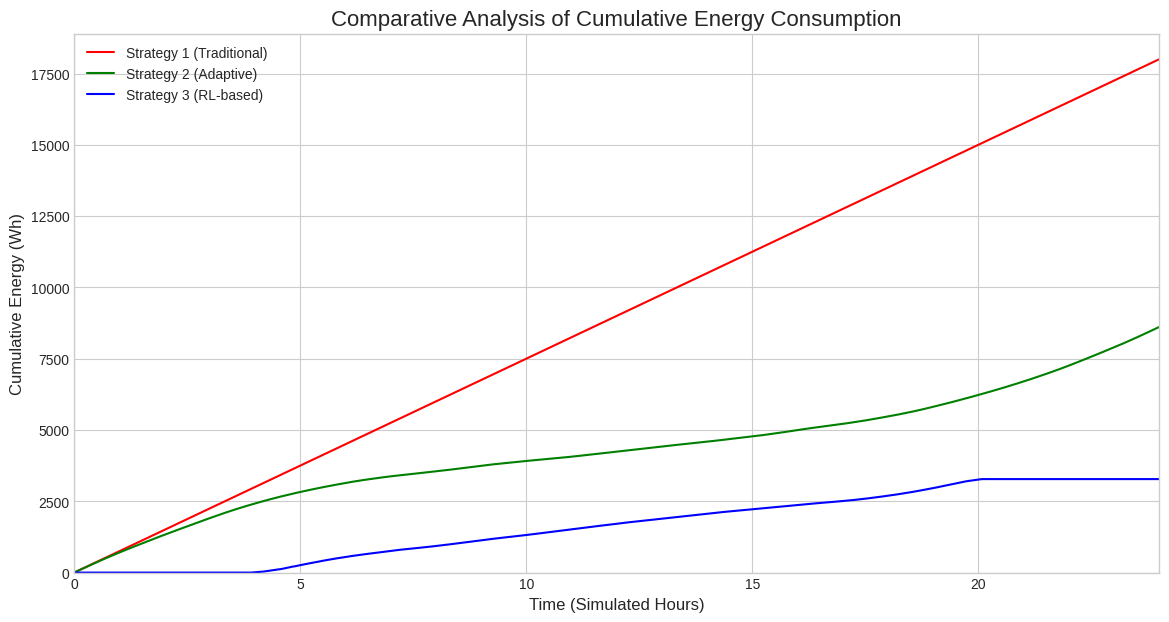

In [2]:
# ===================================================================
# ÉTAPE 1 : IMPORTER ET CONFIGURER
# ===================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Constantes
N_TOTAL = 150
N_PER_FLOOR = 50
P_LED = 5
ACTIVATION_THRESHOLD = 25

# ===================================================================
# ÉTAPE 2 : CHARGER ET PRÉPARER LES DONNÉES DE PUISSANCE (identique à avant)
# ===================================================================
print("--- Préparation des données de puissance ---")

# --- Stratégie 1 ---
df_s1 = pd.read_csv('report_S1_run1.csv', skipfooter=4, engine='python')
df_s1['Timestamp'] = pd.to_datetime(df_s1['Timestamp'])
start_time_s1 = df_s1['Timestamp'].min()
duration_s1 = (df_s1['Timestamp'].max() - start_time_s1).total_seconds()
df_s1['simulated_hours'] = (df_s1['Timestamp'] - start_time_s1).dt.total_seconds() * 24 / duration_s1
df_s1['power_S1'] = N_TOTAL * P_LED

# --- Stratégie 2 ---
df_s2 = pd.read_csv('report_S2_run1.csv', skipfooter=4, engine='python')
df_s2['Timestamp'] = pd.to_datetime(df_s2['Timestamp'])
occupied_spots_count = []
current_occupied = 0
for event_type in df_s2['Event Type']:
    if event_type == 'ARRIVAL': current_occupied += 1
    elif event_type == 'EXIT': current_occupied -= 1
    occupied_spots_count.append(max(0, current_occupied))
df_s2['total_occupied_spots'] = occupied_spots_count
df_s2['power_S2'] = (N_TOTAL - df_s2['total_occupied_spots']) * P_LED
start_time_s2 = df_s2['Timestamp'].min()
duration_s2 = (df_s2['Timestamp'].max() - start_time_s2).total_seconds()
df_s2['simulated_hours'] = (df_s2['Timestamp'] - start_time_s2).dt.total_seconds() * 24 / duration_s2

# --- Stratégie 3 ---
df_s3 = pd.read_csv('report_S3_run0.csv', skipfooter=3, engine='python')
df_s3['Timestamp'] = pd.to_datetime(df_s3['Timestamp'], errors='coerce')
df_s3.dropna(subset=['Timestamp', 'Event Type', 'Assigned Spot'], inplace=True)
counts = {1: 0, 2: 0, 3: 0}
floor_occupancy_data = []
for index, row in df_s3.iterrows():
    try:
        floor = int(row['Assigned Spot'].split(':')[0])
        if row['Event Type'] == 'ARRIVAL': counts[floor] += 1
        elif row['Event Type'] == 'EXIT': counts[floor] -= 1
        counts = {k: max(0, v) for k, v in counts.items()}
    except (ValueError, IndexError): continue
    floor_occupancy_data.append(counts.copy())
df_occupancy = pd.DataFrame(floor_occupancy_data)
df_s3 = pd.concat([df_s3.reset_index(drop=True), df_occupancy.reset_index(drop=True)], axis=1)
df_s3.rename(columns={1: 'occupied_floor_1', 2: 'occupied_floor_2', 3: 'occupied_floor_3'}, inplace=True)
def calculate_power_s3(row):
    power = 0
    if row.get('occupied_floor_1', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_1']) * P_LED
    if row.get('occupied_floor_2', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_2']) * P_LED
    if row.get('occupied_floor_3', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_3']) * P_LED
    return power
df_s3['power_S3'] = df_s3.apply(calculate_power_s3, axis=1)
start_time_s3 = df_s3['Timestamp'].min()
duration_s3 = (df_s3['Timestamp'].max() - start_time_s3).total_seconds()
df_s3['simulated_hours'] = (df_s3['Timestamp'] - start_time_s3).dt.total_seconds() * 24 / duration_s3
print("Données de puissance préparées.")

# ===================================================================
# ÉTAPE 3 : CALCULER L'ÉNERGIE CUMULATIVE POUR CHAQUE STRATÉGIE
# ===================================================================
print("\n--- Calcul de l'énergie cumulative ---")

# Pour chaque DataFrame, on calcule le temps écoulé (delta_t) entre chaque événement
df_s1['delta_t_hours'] = df_s1['simulated_hours'].diff().fillna(0)
df_s2['delta_t_hours'] = df_s2['simulated_hours'].diff().fillna(0)
df_s3['delta_t_hours'] = df_s3['simulated_hours'].diff().fillna(0)

# Énergie (Wh) = Puissance (W) * Temps (h)
# On utilise .shift(1) car la puissance est constante *avant* l'événement
df_s1['energy_step_Wh'] = df_s1['power_S1'].shift(1).fillna(0) * df_s1['delta_t_hours']
df_s2['energy_step_Wh'] = df_s2['power_S2'].shift(1).fillna(0) * df_s2['delta_t_hours']
df_s3['energy_step_Wh'] = df_s3['power_S3'].shift(1).fillna(0) * df_s3['delta_t_hours']

# On calcule la somme cumulative (l'intégrale)
df_s1['cumulative_energy_Wh'] = df_s1['energy_step_Wh'].cumsum()
df_s2['cumulative_energy_Wh'] = df_s2['energy_step_Wh'].cumsum()
df_s3['cumulative_energy_Wh'] = df_s3['energy_step_Wh'].cumsum()

# Afficher les résultats finaux
total_energy_s1 = df_s1['cumulative_energy_Wh'].iloc[-1]
total_energy_s2 = df_s2['cumulative_energy_Wh'].iloc[-1]
total_energy_s3 = df_s3['cumulative_energy_Wh'].iloc[-1]
print(f"Énergie totale S1 (Traditionnelle): {total_energy_s1:.2f} Wh")
print(f"Énergie totale S2 (Adaptative): {total_energy_s2:.2f} Wh")
print(f"Énergie totale S3 (RL-based): {total_energy_s3:.2f} Wh")

# ===================================================================
# ÉTAPE 4 : TRACER LE GRAPHIQUE DE L'ÉNERGIE CUMULATIVE
# ===================================================================
print("\n--- Génération du graphique d'énergie cumulative ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_s1['simulated_hours'], df_s1['cumulative_energy_Wh'], label='Strategy 1 (Traditional)', color='red')
ax.plot(df_s2['simulated_hours'], df_s2['cumulative_energy_Wh'], label='Strategy 2 (Adaptive)', color='green')
ax.plot(df_s3['simulated_hours'], df_s3['cumulative_energy_Wh'], label='Strategy 3 (RL-based)', color='blue')

# Mettre en forme le graphique
ax.set_title('Comparative Analysis of Cumulative Energy Consumption', fontsize=16)
ax.set_xlabel('Time (Simulated Hours)', fontsize=12)
ax.set_ylabel('Cumulative Energy (Wh)', fontsize=12)
ax.set_xlim(0, 24)
ax.set_ylim(bottom=0)
ax.legend()
ax.grid(True)

# Sauvegarder et afficher
plt.savefig('figure_cumulative_energy.png', dpi=300)
print("Graphique d'énergie cumulative sauvegardé sous 'figure_cumulative_energy.png'")
plt.show()

In [ ]:
# ===================================================================
# ÉTAPE 1 : IMPORTER LES BIBLIOTHÈQUES ET DÉFINIR LES CONSTANTES
# ===================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Constantes de la simulation
N_TOTAL = 150
N_PER_FLOOR = 50
P_LED = 5  # Puissance par LED en Watts
ACTIVATION_THRESHOLD = 25 # Seuil d'activation de 50%

# ===================================================================
# ÉTAPE 2 : CHARGER ET PRÉPARER LES DONNÉES
# ===================================================================
print("--- Préparation des données de simulation ---")

# --- Stratégie 1 : Données ---
df_s1 = pd.read_csv('report_S1_run1.csv', skipfooter=4, engine='python')
df_s1['Timestamp'] = pd.to_datetime(df_s1['Timestamp'])

# --- Stratégie 2 : Données ---
df_s2 = pd.read_csv('report_S2_run1.csv', skipfooter=4, engine='python')
df_s2['Timestamp'] = pd.to_datetime(df_s2['Timestamp'])

# --- Stratégie 3 : Données (Run Médian) ---
df_s3 = pd.read_csv('report_S3_run0.csv', skipfooter=3, engine='python')
df_s3['Timestamp'] = pd.to_datetime(df_s3['Timestamp'], errors='coerce')
df_s3.dropna(subset=['Timestamp', 'Event Type', 'Assigned Spot'], inplace=True)

print("Fichiers CSV chargés avec succès.")


# ===================================================================
# ÉTAPE 3 : DÉFINIR LA FONCTION DE CALCUL D'ÉNERGIE PAR TRANCHE
# ===================================================================
def calculate_energy_in_period_kwh(df, power_col, start_hour, end_hour):
    """Calcule l'énergie consommée (en kWh) dans une tranche horaire donnée."""
    # Sélectionner les données dans la tranche horaire
    period_df = df[(df['simulated_hours'] >= start_hour) & (df['simulated_hours'] < end_hour)].copy()
    if period_df.empty:
        return 0

    # Recalculer le delta_t pour cette tranche
    period_df['delta_t'] = period_df['simulated_hours'].diff().fillna(0)

    # Calculer l'énergie en Wh
    energy_wh = np.sum(period_df[power_col].shift(1).fillna(0) * period_df['delta_t'])

    # Convertir en kWh
    return energy_wh / 1000

# ===================================================================
# ÉTAPE 4 : TRAITER CHAQUE STRATÉGIE ET CALCULER LA PUISSANCE
# ===================================================================

# --- Traitement S1 ---
start_time_s1 = df_s1['Timestamp'].min()
duration_s1 = (df_s1['Timestamp'].max() - start_time_s1).total_seconds()
df_s1['simulated_hours'] = (df_s1['Timestamp'] - start_time_s1).dt.total_seconds() * 24 / duration_s1
df_s1['power_S1'] = N_TOTAL * P_LED

# --- Traitement S2 ---
occupied_spots_count = []
current_occupied = 0
for event_type in df_s2['Event Type']:
    if event_type == 'ARRIVAL': current_occupied += 1
    elif event_type == 'EXIT': current_occupied -= 1
    occupied_spots_count.append(max(0, current_occupied))
df_s2['total_occupied_spots'] = occupied_spots_count
df_s2['power_S2'] = (N_TOTAL - df_s2['total_occupied_spots']) * P_LED
start_time_s2 = df_s2['Timestamp'].min()
duration_s2 = (df_s2['Timestamp'].max() - start_time_s2).total_seconds()
df_s2['simulated_hours'] = (df_s2['Timestamp'] - start_time_s2).dt.total_seconds() * 24 / duration_s2

# --- Traitement S3 ---
counts = {1: 0, 2: 0, 3: 0}
floor_occupancy_data = []
for index, row in df_s3.iterrows():
    try:
        floor = int(row['Assigned Spot'].split(':')[0])
        if row['Event Type'] == 'ARRIVAL': counts[floor] += 1
        elif row['Event Type'] == 'EXIT': counts[floor] -= 1
        counts = {k: max(0, v) for k, v in counts.items()}
    except (ValueError, IndexError): continue
    floor_occupancy_data.append(counts.copy())
df_occupancy = pd.DataFrame(floor_occupancy_data)
df_s3 = pd.concat([df_s3.reset_index(drop=True), df_occupancy.reset_index(drop=True)], axis=1)
df_s3.rename(columns={1: 'occupied_floor_1', 2: 'occupied_floor_2', 3: 'occupied_floor_3'}, inplace=True)
def calculate_power_s3(row):
    power = 0
    if row.get('occupied_floor_1', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_1']) * P_LED
    if row.get('occupied_floor_2', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_2']) * P_LED
    if row.get('occupied_floor_3', 0) >= ACTIVATION_THRESHOLD: power += (N_PER_FLOOR - row['occupied_floor_3']) * P_LED
    return power
df_s3['power_S3'] = df_s3.apply(calculate_power_s3, axis=1)
start_time_s3 = df_s3['Timestamp'].min()
duration_s3 = (df_s3['Timestamp'].max() - start_time_s3).total_seconds()
df_s3['simulated_hours'] = (df_s3['Timestamp'] - start_time_s3).dt.total_seconds() * 24 / duration_s3

print("Calculs de puissance instantanée terminés.")

# ===================================================================
# ÉTAPE 5 : CALCULER L'ÉNERGIE PAR TRANCHE ET CONSTRUIRE LE TABLEAU
# ===================================================================
print("\n--- Calcul de l'énergie par tranche horaire en kWh ---")

# Définir les tranches horaires
time_periods = {
    'Night (00-06h)': (0, 6),
    'Morning Rush (06-10h)': (6, 10),
    'Peak Hours (10-16h)': (10, 16),
    'Evening Peak (16-21h)': (16, 21),
    'Late Evening (21-24h)': (21, 24)
}

results_kwh = {}

# Calculer pour chaque période et chaque stratégie
for period_name, (start, end) in time_periods.items():
    energy_s1_kwh = calculate_energy_in_period_kwh(df_s1, 'power_S1', start, end)
    energy_s2_kwh = calculate_energy_in_period_kwh(df_s2, 'power_S2', start, end)
    energy_s3_kwh = calculate_energy_in_period_kwh(df_s3, 'power_S3', start, end)
    results_kwh[period_name] = {'S1_kWh': energy_s1_kwh, 'S2_kWh': energy_s2_kwh, 'S3_kWh': energy_s3_kwh}

# Calculer les totaux
total_s1_kwh = sum(p['S1_kWh'] for p in results_kwh.values())
total_s2_kwh = sum(p['S2_kWh'] for p in results_kwh.values())
total_s3_kwh = sum(p['S3_kWh'] for p in results_kwh.values())
results_kwh['Total (24 hours)'] = {'S1_kWh': total_s1_kwh, 'S2_kWh': total_s2_kwh, 'S3_kWh': total_s3_kwh}

# Créer un DataFrame pandas pour l'affichage
report_df = pd.DataFrame.from_dict(results_kwh, orient='index')

# Calculer les économies en pourcentage
report_df['Savings_S2_%'] = ((report_df['S1_kWh'] - report_df['S2_kWh']) / report_df['S1_kWh']).fillna(0) * 100
report_df['Savings_S3_%'] = ((report_df['S1_kWh'] - report_df['S3_kWh']) / report_df['S1_kWh']).fillna(0) * 100

# Formater pour une meilleure lisibilité
pd.options.display.float_format = '{:,.3f}'.format
print("\n--- TABLEAU RÉCAPITULATIF DES ÉCONOMIES D'ÉNERGIE (en kWh) ---")
print(report_df[['S1_kWh', 'S2_kWh', 'S3_kWh', 'Savings_S2_%', 'Savings_S3_%']])

--- Préparation des données de simulation ---
Fichiers CSV chargés avec succès.
Calculs de puissance instantanée terminés.

--- Calcul de l'énergie par tranche horaire en kWh ---

--- TABLEAU RÉCAPITULATIF DES ÉCONOMIES D'ÉNERGIE (en kWh) ---
                       S1_kWh  S2_kWh  S3_kWh  Savings_S2_%  Savings_S3_%
Night (00-06h)          4.477   3.133   0.537        30.018        88.011
Morning Rush (06-10h)   2.965   0.763   0.768        74.265        74.091
Peak Hours (10-16h)     4.477   1.075   1.047        75.982        76.616
Evening Peak (16-21h)   3.721   1.689   0.903        54.596        75.743
Late Evening (21-24h)   2.208   1.873   0.000        15.196       100.000
Total (24 hours)       17.849   8.534   3.254        52.188        81.766
